<img src="images/banner.png" style="width: 100%;">

In [2]:
import numpy as np
import pandas as pd

# Introduction to Information Retrieval

In [3]:
# !conda install nltk -y # You might need to install nltk for the text preprocessing pipeline

Adapted from notebooks of **Prof Christian Alis**, revised and edited by **Leodegario Lorenzo II**

Tackling the problem of information retrieval is a logical starting point for introducing the issues, paradigms and techniques in solving data analytics problems. The problem of information retrieval can be stated as follows. Given a database or corpus $D$ of documents, find the $k$ most similar documents from a given query document or exemplar $q$. 

Although the documents that are referred to in the problem are text documents, it can be readily generalized to any object. In this course, we will work with this generalized problem. Thus, when we refer to _information_ retrieval, we actually refer to _object_ retrieval. That is, finding the objects most similar to a query or exemplar object.

To solve the information retrieval problem, we need to:

1. represent each document or object in a form that is easy to be worked on by algorithms;
2. define a measure of similarity between documents or objects;
3. return the most similar objects based on the similarity measure.

We will demonstrate how we will perform each of the steps. Although, we will only use the simplest algorithm for performing step 3 but verify that there are more efficient algorithms for performing this step.

For this demonstration, we will use a subset of the **[20 newsgroups text dataset](https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset)**, which we will load using `sklearn`.

In [4]:
from sklearn.datasets import fetch_20newsgroups

data_newsgroups = fetch_20newsgroups(
    subset="all",
    categories=["comp.graphics", "rec.autos"],
    shuffle=False,
    remove=("headers", "footers", "quotes"),
)

# Remove documents comprising only an empty string
docs, target = zip(
    *[
        (doc, target)
        for doc, target in zip(
            data_newsgroups["data"], data_newsgroups["target"]
        )
        if doc.strip()
    ]
)

docs = np.array(docs)
target = np.array(target)

The dataset contains post from newsgroup split which has been labeled into certain topics. For this subset we only get posts from the `comp.graphics` and `rec.autos` categories.

In [5]:
target

array([1, 1, 1, ..., 1, 0, 1], shape=(1892,))

In [8]:
print(docs[target == 1][0])


<apparently you're not a woman - my husband hates the auto door locks
<feels safer in a car that locks easily (in addition to watching around
<in a secluded spot, etc - have my keys ready to open the door so I'm


In [9]:
print(docs[target == 0][0])

In regards to fractal commpression, I have seen 2 fractal compressed "movies".
They were both fairly impressive.  The first one was a 64 gray scale "movie" of
Casablanca, it was 1.3MB and had 11 minutes of 13 fps video.  It was a little
grainy but not bad at all.  The second one I saw was only 3 minutes but it
had 8 bit color with 10fps and measured in at 1.2MB.

I consider the fractal movies a practical thing to explore.  But unlike many 
other formats out there, you do end up losing resolution.  I don't know what
kind of software/hardware was used for creating the "movies" I saw but the guy
that showed them to me said it took 5-15 minutes per frame to generate.  But as
I said above playback was 10 or more frames per second.  And how else could you
put 11 minutes on one floppy disk?


## 1 Data Preparation

Since we are dealing with text data, we'll perform a simple text data preprocessing pipeline to **vectorize** the dataset. We perform the following steps using `sklearn`'s `CountVectorizer`:

1. Tokenization and Case Folding
2. Stopwords Removal
3. Word Vectorization

In [11]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
count_vectorizer = CountVectorizer(
    token_pattern=r"\w+",
    stop_words=stopwords.words('english'),
    ngram_range=(1, 3),
    lowercase=True
)

In [13]:
count_vectorizer = CountVectorizer(
    token_pattern=r"\w+",
    stop_words=stopwords.words('english'),
    lowercase=True
)

In [14]:
count_vectorizer.fit(docs)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.","['i', 'me', ...]"
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'\\w+'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [17]:
len(count_vectorizer.get_feature_names_out())

20213

In [18]:
count_vectorizer.transform(docs)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 118688 stored elements and shape (1892, 20213)>

In [19]:
df_bow_ng = pd.DataFrame.sparse.from_spmatrix(
    count_vectorizer.transform(docs),
    columns=count_vectorizer.get_feature_names_out(),
)

In [20]:
df_bow_ng

,0,00,000,0000,000005102000,000100255pixel,0007,000mi,000miles,000usd,...,zsoft,zug,zur,zurich,zvi,zx,zyda,zyxel,ú,þ
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1887,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1888,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1889,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1890,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
df_bow_ng.iloc[0].loc[df_bow_ng.iloc[0] > 0]

addition      1
apparently    1
around        1
auto          1
car           1
door          2
easily        1
etc           1
feels         1
hates         1
husband       1
keys          1
locks         2
open          1
ready         1
safer         1
secluded      1
spot          1
watching      1
woman         1
Name: 0, dtype: Sparse[int64, 0]

In [24]:
print(docs[0])


<apparently you're not a woman - my husband hates the auto door locks
<feels safer in a car that locks easily (in addition to watching around
<in a secluded spot, etc - have my keys ready to open the door so I'm


## 2 Similarity Measures

Now that we have converted our objects and documents into their vector space representation, we now have to define a measure of how similar or different two objects or documents are. Recall that vectors can be thought of as arrows with its tip pointing to where that point is in space. We can then use the distance of those points or the angle between the arrows as measures of similarity between the objects or documents that they represent.

### $L_p$-norm

$L_p$-norm is basically the distance between two vectors or points. The $L_p$-norm between two vectors $\vec v_1$ and $\vec v_2$ is
$$L_p(\vec v_1, \vec v_2) = \left(\sum_i \left| \vec v_{1_i} - \vec v_{2_i} \right|^p \right)^{1/p}$$

If $p=2$, it is the usual Euclidean distance. If $p=1$, it is known as the city block or Manhattan distance.

In [25]:
def lpnorm(vec1, vec2, p=2):
    """Compute the L_p-norm distance between vec1 and vec2

    If `vec1` and `vec2` are same-sized matrices, an ndarray of the L_p-norm
    of corresponding rows will be returned instead.

    Parameters
    ----------
    vec1 : ndarray
        First vector
    vec2 : ndarray
        Second vector
    p : int or float, optional
        Order of L_p norm; the `p` in L_p norm

    Returns
    -------
    float
        L_p norm distance of `vec1` and `vec2`
    """
    if len(vec1.shape) == 1:
        return (np.abs(vec1-vec2)**p).sum()**(1./p)
    else:
        return (np.abs(vec1-vec2)**p).sum(axis=1)**(1./p)

### Cosine similarity

The cosine similarity between two vectors $\vec v_1$ and $\vec v_2$ is related to the angle between them and is given by
$$S_\text{cos}(\vec v_1, \vec v_2) = \frac{\vec v_1 \cdot \vec v_2}{\left|\left|\vec v_1\right|\right| \left|\left| \vec v_2 \right|\right|}.$$

If the vectors are nonnegative, which is the case for BoW vectors, its range is $[0,1]$ with 1 implying the two vectors are aligned (most similar) and 0 implying they are perpendicular (least similar).

In [26]:
def cossim(vec1, vec2):
    """Compute cosine similarity between vec1 and vec2

    If `vec1` and `vec2` are same-sized matrices, an ndarray of the cosine
    similarity of corresponding rows will be returned instead.

    Parameters
    ----------
    vec1 : ndarray
        First vector
    vec2 : ndarray
        Second vector

    Returns
    -------
    float
        cosine similarity of `vec1` and `vec2`
    """
    return (np.dot(vec1, vec2) /
            (np.sqrt((vec1**2).sum()) * np.sqrt((vec2**2).sum())))

In [27]:
cos_dist = lambda x, y: 1 - cossim(x, y)

### Other distance measures

The $L_p$-norm and cosine distances are the most popular distance measures because of their simplicity, computational performance and tractability. These are the measures that we will use for this course and even for higher courses. However, there are other distance measures that exist. Some of them can be used for different data types, however, not all of them follow the triangle inequality and can be computationally expensive.

Some of the other distance/similarity measures that you may encounter are:

* **Mahalanobis distance**

This is the Euclidean distance between two points $\vec{x}$ and $\vec{y}$, taking into account the distribution where they are from as describe by the covariance $\mathbf{S}$, 

$$Dist(\vec{v}_1 ,\vec{v}_2) = \sqrt{(\vec{v}_1 - \vec{v}_2)^\mathsf{T} \mathbf{S}^{-1} (\vec{v}_1 - \vec{v}_2)}.$$


When one of the vectors (say $\vec{y}$) is the mean $\vec{\mu}$, it is like the $z$-score of $\vec{x}$ taking into account the shape of the distribution. This is exactly the case when coordinates are rotated to coincide with the principal axes.

* **Jaccard distance**

A measure of similarity between two sets $S_1$ and $S_2$,

$$Dist(S_1, S_2) = 1 - \frac{\left|S_1 \cap S_2\right|}{\left|S_1 \cup S_2\right|}$$

* **Hamming distance**

Given two equal-length strings $S_1$ and $S_2$, the hamming distance is the number of mismatches between the two strings.

* **Dynamic time warping distance**

Measures the distance between two unequal-length time series or sequence by stretching them along the axis.

* **Edit distance**

Number of operations to make two strings equal. The allowed operations depend on the type of edit distance:

* The Levenshtein distance allows deletion, insertion and substitution.
* The Longest common subsequence (LCS) distance allows only insertion and deletion, not substitution.
* The Hamming distance allows only substitution, hence, it only applies to strings of the same length.
* The Damerau–Levenshtein distance allows insertion, deletion, substitution, and the transposition of two adjacent characters.



## 3 Retrieval and Ranking

Now that we have represented our objects and documents as vectors and also defined measures for similarity that we can use, we can now look for similar objects or documents of a given exemplar object or document. The algorithm for doing so is quite straightforward: 

1. transform the exemplar into the same representation as the objects in the database
2. compute the similarity or distance of the exemplar with each of the objects in the database
3. return the objects in the database with the greatest similarity or smallest distance

We do so by using a helper function that returns the top `k` most similar objects given a `query` and a database of vector-represented `objects`, using a distance function `dist`.

In [30]:
def nearest_k(query, objects, k, dist):
    """Return the indices to objects most similar to query

    Parameters
    ----------
    query : ndarray
        query object represented in the same form vector representation as the
        objects
    objects : ndarray
        vector-represented objects in the database; rows correspond to 
        objects, columns correspond to features
    k : int
        number of most similar objects to return
    dist : function
        accepts two ndarrays as parameters then returns their distance

    Returns
    -------
    ndarray
        Indices to the most similar objects in the database
    """
    return np.argsort([dist(query, obj) for obj in objects], kind='stable')[:k]

As an example, let's look at the `10` most similar posts to the newsgroup dataset first post:

In [28]:
df_bow_ng.iloc[0]

0               0
00              0
000             0
0000            0
000005102000    0
               ..
zx              0
zyda            0
zyxel           0
ú               0
þ               0
Name: 0, Length: 20213, dtype: Sparse[int64, 0]

In [34]:
result = nearest_k(query=df_bow_ng.iloc[0].to_numpy(),
                   objects=df_bow_ng.to_numpy(),
                   k=11,
                   dist=cos_dist)

/var/folders/kd/6gvmhbqn5cq8zbhpl_xgf08h9mszfk/T/ipykernel_13397/2806015838.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (np.dot(vec1, vec2) /


In [35]:
result

array([   0, 1889,  385,  737, 1070, 1419,  284,  248, 1332,  647,   30])

In [33]:
target[0]

np.int64(1)

In [36]:
target[result]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [37]:
print(docs[result][0])


<apparently you're not a woman - my husband hates the auto door locks
<feels safer in a car that locks easily (in addition to watching around
<in a secluded spot, etc - have my keys ready to open the door so I'm


In [38]:
print(docs[result][1])

it hauls butt, handles nice, but is junk.  i drove a brand new one for a day
as a loaner.  the key was already rusting...seems they stamp their keys out
of pot-metal.  all the controls seemed really junk...clutch was heavy.
door locks, power buttons, sunroof controls etc.  seemed really cheap.
no way i would pay 24k for this baby.  no airbag either.  i also drove a svx
for a day...stickered at 30k, but going out the door for 21k...a much better
buy, imo.  although it is more of a sports touring coupe...roomy etc.
the corrado is more of a small sports car.  the ergonomics and leather in the
svx was twice as nice as the corrado's.  both had smooth strong engines.





## 4 Evaluation of the IR System

To evaluate the performance of our pipeline, we need to specify whether each returned object is relevant as well as we need to know how many relevant objects are in the database. This is what is known as a form of external validation. If we let the user confirm whether each item in the result is relevant, we can use it as a feedback and improve the results e.g., by using [Rocchio's algorithm](https://en.wikipedia.org/wiki/Rocchio_algorithm). Of course, getting feedback from users may not be straightforward. In fact, we will work with implicit feedback when we develop recommendation systems in DMW2. Furthermore, knowing the number of relevant objects in the database is somewhat a chicken-and-egg problem. 

For now, we'll make some assumptions. We assume that, in the newsgroup dataset, if we pick a post from a newsgroup as the query, relevant posts are those that came from the same newsgroup.

Let's compute our precision and recall from our test query from the previous section:

### Confusion Matrix

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [40]:
predictions = np.zeros(len(target))
predictions[result[1:]] = 1

In [41]:
result[1:]

array([1889,  385,  737, 1070, 1419,  284,  248, 1332,  647,   30])

In [42]:
target

array([1, 1, 1, ..., 1, 0, 1], shape=(1892,))

In [43]:
predictions

array([0., 0., 0., ..., 1., 0., 0.], shape=(1892,))

In [44]:
predictions.sum()

np.float64(10.0)

In [45]:
confusion_matrix(target, predictions)

array([[955,   0],
       [927,  10]])

In [46]:
df_confusion = pd.DataFrame(confusion_matrix(target, predictions),
                            index=['Not Relevant', 'Relevant'],
                            columns=['Not Returned', 'Returned'])
df_confusion

,Not Returned,Returned
Not Relevant,955,0
Relevant,927,10


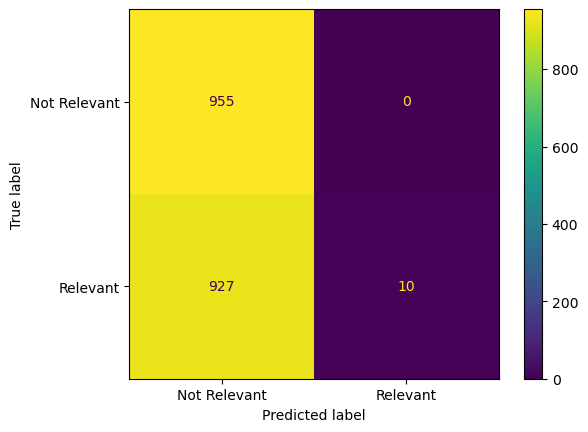

In [47]:
disp = ConfusionMatrixDisplay(confusion_matrix=df_confusion.to_numpy(),
                              display_labels=['Not Relevant', 'Relevant'])
disp.plot();

### Precision and Recall

To compute precision and recall we an use the formula:

* Precision
  - $P = \frac{r}{k} = \frac{TP}{TP + FP}$
  - fraction of relevant results
* Recall
  - $R = \frac{r}{n} = \frac{TP}{TP + FN}$
  - fraction of relevant objects in the database that were returned
  
Both precision and recall are from 0 to 1 with 1 the best value.

In [48]:
df_confusion

,Not Returned,Returned
Not Relevant,955,0
Relevant,927,10


In [49]:
precision = df_confusion.loc['Relevant', 'Returned'] / df_confusion.loc[:, 'Returned'].sum()
precision

np.float64(1.0)

In [58]:
df_confusion.loc[:, 'Returned']

Not Relevant     0
Relevant        10
Name: Returned, dtype: int64

In [57]:
df_confusion.loc['Relevant']

Not Returned    927
Returned         10
Name: Relevant, dtype: int64

In [50]:
recall = df_confusion.loc['Relevant', 'Returned'] / df_confusion.loc['Relevant'].sum()
recall

np.float64(0.010672358591248666)

### $F$-measure

If we want to use a single number to describe both precision and recall, we can use the $F$-measure or $F$-score,

$$F_\beta = (1 + \beta^2) \cdot \frac{P \cdot R}{(\beta^2 \cdot P) + R}.$$

In the usual case, $\beta=1$, it is the harmonic mean of precision and recall, and is known as the $F_1$-measure or balance $F$-measure. It gives equal importance to both precision and recall. If it is more important that the results that we get are correct than being able to identify all relevant objects, then we give more importance to precision and we set $0 < \beta < 1$. If a false negative is less desired than being able to correctly identify relevant objects, then we give more importance to recall and set $\beta > 1$.

In [51]:
def f_measure(precision, recall, beta=1):
    return (1+beta**2) * (precision*recall) / ((beta**2*precision)+recall)

In [52]:
f_measure(precision, recall)

np.float64(0.021119324181626188)

### Precision-Recall Curve

The thing with precision and recall is that their value is influenced by the choice of $k$. If we set $k=1$, for example, then it's very likely that the object that we returned is relevant, thus, a precision value of 1, but recall will be small because you won't be able to return all relevant objects. At the other extreme, if we set $k=N$ where $N$ is the number of objects in the database then obviously, recall with have a value of 1 but precision suffers because irrelevant objects will be included in the results. Thus, there is a trade-off between precision and recall and this can be visualized using a precision-recall (PR) curve. 

In [55]:
import matplotlib.pyplot as plt

In [54]:
def pr_curve(query, objects, dist, actual, all_labels):
    """Draw PR curve

    Parameters
    ----------
    query: array-like
        find objects similar to this query
    objects: ndarray
        database of objects to search in
    dist: function
        function that returns the distance of two input `ndarray`s
    actual: int
        class label
    all_labels: array-like
        label of each object in the database

    Returns
    -------
    matplotlib.Axes
        rendered PR curve
    """
    all_labels = np.asarray(all_labels)
    results = nearest_k(query, objects, len(all_labels), dist)
    rs = (all_labels[results] == actual).cumsum()
    N = (all_labels == actual).sum()
    precisions = rs / np.arange(1, len(rs) + 1)
    recalls = rs / N
    recalls = [0] + recalls.tolist()
    precisions = [1] + precisions.tolist()

    fig, ax = plt.subplots()
    ax.set_aspect("equal")
    ax.step(recalls, precisions, where="post")
    ax.fill_between(recalls, precisions, step="post", alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("recall")
    ax.set_ylabel("precision")

    return ax

/Users/llorenzo/miniforge3/envs/bsdsba2028-dmw-2301/lib/python3.12/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


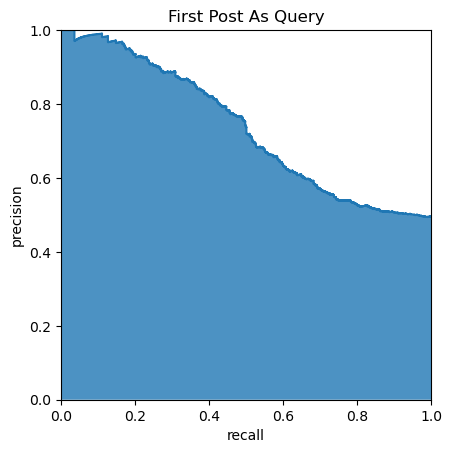

In [56]:
from scipy.spatial.distance import cosine

ax = pr_curve(
    df_bow_ng.sparse.to_dense().iloc[0],
    df_bow_ng.to_numpy(),
    cosine,
    target[0],
    target
)
ax.set_title('First Post As Query');

### AUC-PR / Average Precision

Ideally, we want the entire area to be covered--we want the precision to be always 1 regardless of the value of recall. Recall is always from 0 ($k=0$) to 1 ($k=N$). To quantify this, we can compute the area under the PR curve (AUC-PR). The desired value is 1.

In [59]:
def auc_pr(query, objects, dist, actual, all_labels):
    """Compute area under the PR curve

    Parameters
    ----------
    query: array-like
        find objects similar to this query
    objects: numpy.ndarray
        database of objects to search in
    dist: function
        function that returns the distance of two input `ndarray`s
    actual: int
        class label
    all_labels: array-like
        label of each object in the database

    Returns
    -------
    float
        area under the PR curve
    """
    from scipy.integrate import trapezoid

    all_labels = np.asarray(all_labels)
    results = nearest_k(query, objects, len(all_labels), dist)
    rs = (all_labels[results] == actual).cumsum()
    N = (all_labels == actual).sum()
    precisions = rs / np.arange(1, len(rs) + 1)
    recalls = rs / N
    recalls = [0] + recalls.tolist()
    precisions = [1] + precisions.tolist()

    return trapezoid(precisions, recalls)

In [60]:
auc_pr(
    df_bow_ng.sparse.to_dense().iloc[0],
    df_bow_ng.to_numpy(),
    cosine,
    target[0],
    target,
)

/Users/llorenzo/miniforge3/envs/bsdsba2028-dmw-2301/lib/python3.12/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


np.float64(0.7345666047960411)

### Mean Precision@k and Mean Average Precision

So far, the effectiveness measure we considered only covers the performance of the IR system for a single query. If we want to compute for the effectiveness of the IR system over a set of queries, the arithmetic mean is usually taken.

#### P@10

In [61]:
precisions_at_10 = []
for i, query in df_bow_ng.iloc[:10].iterrows():
    result = nearest_k(query.to_numpy(), df_bow_ng.to_numpy(), 11, cosine)

    # Get prediction
    if target[i]:
        query_prediction = np.zeros(len(target))
        query_prediction[result[1:]] = 1
        query_cf = confusion_matrix(target, query_prediction)
        tp = query_cf[1][1]
        fp = query_cf[0][1]
        precision_at_10 = tp / (tp + fp)
    else:
        query_prediction = np.ones(len(target))
        query_prediction[result[1:]] = 0
        query_cf = confusion_matrix(target, query_prediction)
        tp = query_cf[0][0]
        fp = query_cf[1][0]
        precision_at_10 = tp / (tp + fp)

    precisions_at_10.append(precision_at_10)
precisions_at_10

/Users/llorenzo/miniforge3/envs/bsdsba2028-dmw-2301/lib/python3.12/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/Users/llorenzo/miniforge3/envs/bsdsba2028-dmw-2301/lib/python3.12/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/Users/llorenzo/miniforge3/envs/bsdsba2028-dmw-2301/lib/python3.12/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/Users/llorenzo/miniforge3/envs/bsdsba2028-dmw-2301/lib/python3.12/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
/Users/llorenzo/miniforge3/envs/bsdsba2028-dmw-2301/lib/python3.12/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math

[np.float64(1.0),
 np.float64(0.7),
 np.float64(1.0),
 np.float64(0.8),
 np.float64(0.8),
 np.float64(0.2),
 np.float64(0.7),
 np.float64(1.0),
 np.float64(0.7),
 np.float64(0.9)]

In [62]:
np.mean(precision_at_10)

np.float64(0.9)

#### Mean Average Precision

In [63]:
average_precisions = []
for i, query in df_bow_ng.iloc[:10].iterrows():
    average_precision = auc_pr(
        query,
        df_bow_ng.to_numpy(),
        cosine,
        target[i],
        target,
    )
    average_precisions.append(average_precision)
average_precisions

/Users/llorenzo/miniforge3/envs/bsdsba2028-dmw-2301/lib/python3.12/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


[np.float64(0.7345666047960411),
 np.float64(0.5706242538285698),
 np.float64(0.7279183161040237),
 np.float64(0.5506676867941976),
 np.float64(0.6458450326304481),
 np.float64(0.44999849168220807),
 np.float64(0.5286342534701629),
 np.float64(0.6034303105105052),
 np.float64(0.5976536792673526),
 np.float64(0.5292591401790863)]

In [64]:
np.mean(average_precisions)

np.float64(0.5938597769262597)

<img src="images/banner-down.png" style="width: 100%;">